# Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1.Explore the Dataset

In [2]:
image_path = 'CUB_200_2011/images/198.Rock_Wren/Rock_Wren_0035_188998.jpg'
mask_path = 'segmentations/198.Rock_Wren/Rock_Wren_0035_188998.png'

Load image and convert BGR (OpenCV default) to RGB (Matplotlib default)

In [3]:
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Load the ground truth segmentation mask in grayscale

In [4]:
gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Plotting

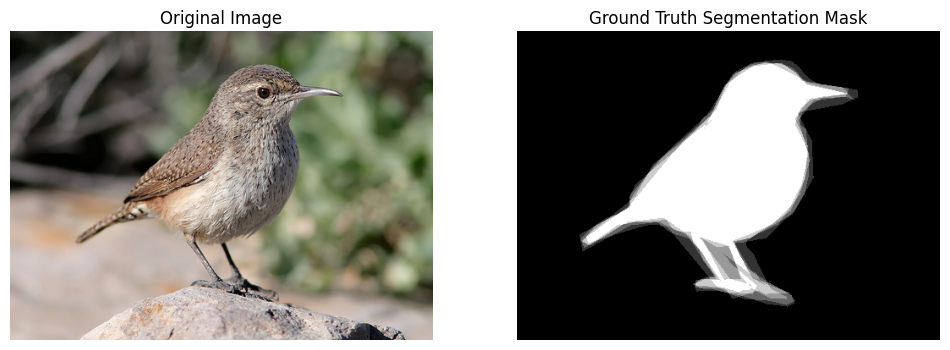

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title('Ground Truth Segmentation Mask')
axes[1].axis('off')

plt.show()

# 2.Segmentation Algorithms & Distance Metrics

Preprocess Ground Truth Mask to be strictly binary (0 and 1)

In [6]:
_, gt_binary = cv2.threshold(gt_mask, 127, 1, cv2.THRESH_BINARY)

Otsu's Thresholding Algorithm

In [7]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Apply a blur

In [8]:
blurred_gray = cv2.GaussianBlur(gray_img, (5, 5), 0)

In [9]:
_, otsu_mask = cv2.threshold(blurred_gray, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# K-Means Clustering Algorithm

Reshape

In [10]:
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

Apply K-means

In [11]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 2
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

Reshape labels back to the original image shape

In [12]:
kmeans_mask = labels.reshape((img.shape[0], img.shape[1]))

Distance Metrics Functions

In [13]:
if kmeans_mask[0, 0] == 1:
    kmeans_mask = 1 - kmeans_mask
def calculate_iou(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask)
    union = np.logical_or(pred_mask, true_mask)
    return np.sum(intersection) / np.sum(union)

def calculate_dice(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask)
    return 2.0 * np.sum(intersection) / (np.sum(pred_mask) + np.sum(true_mask))

# Calculate and Print Distances

In [14]:
print("--- Distance Metrics ---")
print(f"Otsu's Method -> IoU: {calculate_iou(otsu_mask, gt_binary):.4f} | Dice: {calculate_dice(otsu_mask, gt_binary):.4f}")
print(f"K-Means Method -> IoU: {calculate_iou(kmeans_mask, gt_binary):.4f} | Dice: {calculate_dice(kmeans_mask, gt_binary):.4f}")

--- Distance Metrics ---
Otsu's Method -> IoU: 0.1152 | Dice: 0.2066
K-Means Method -> IoU: 0.1967 | Dice: 0.3287


# Visualize the Results

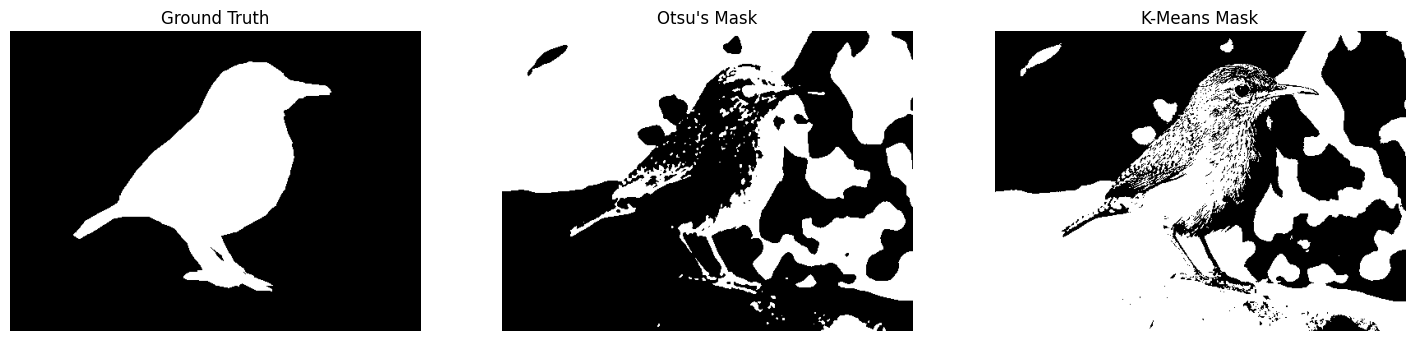

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(gt_binary, cmap='gray'); axes[0].set_title('Ground Truth')
axes[1].imshow(otsu_mask, cmap='gray'); axes[1].set_title("Otsu's Mask")
axes[2].imshow(kmeans_mask, cmap='gray'); axes[2].set_title('K-Means Mask')

for ax in axes:
    ax.axis('off')
plt.show()

# 3.Edge Detection

Basic Sobel Edge Detection

In [16]:
sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

Normalize

In [17]:
sobel_combined = np.uint8(255 * sobel_combined / np.max(sobel_combined))

# Canny Edge Detection

Apply Gaussian

In [18]:
blurred_for_canny = cv2.GaussianBlur(gray_img, (5, 5), 0)

Calculate optimal thresholds

In [19]:
v = np.median(blurred_for_canny)
sigma = 0.33
lower_threshold = int(max(0, (1.0 - sigma) * v))
upper_threshold = int(min(255, (1.0 + sigma) * v))

Apply Canny

In [20]:
canny_edges = cv2.Canny(blurred_for_canny, lower_threshold, upper_threshold)

# Visualize Comparison

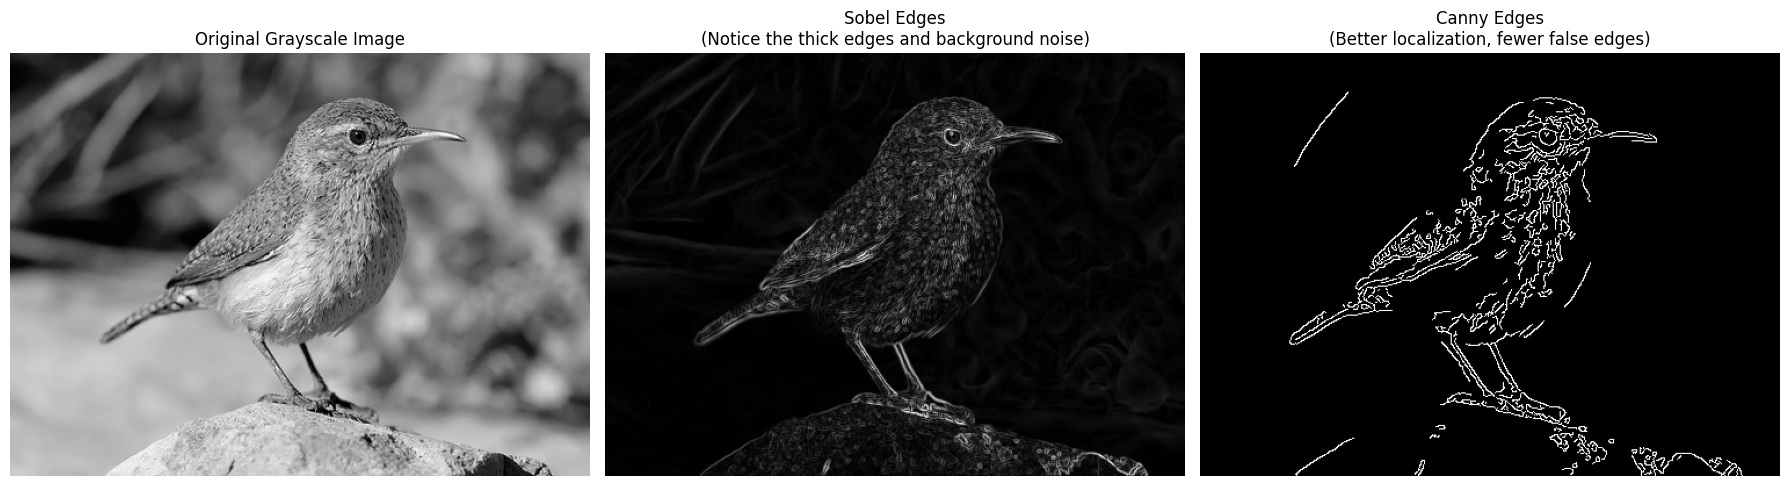

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Grayscale Image')

axes[1].imshow(sobel_combined, cmap='gray')
axes[1].set_title('Sobel Edges\n(Notice the thick edges and background noise)')

axes[2].imshow(canny_edges, cmap='gray')
axes[2].set_title('Canny Edges\n(Better localization, fewer false edges)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()